In [81]:
import os
import numpy as np
import matplotlib.pyplot as plt
import json

In [82]:
DATA_ROOT = "/workspace/yb-soc-two-body-loss/data/fig2ab"

In [83]:
def query_condition(name):
    return True

for name in os.listdir(DATA_ROOT):
    if query_condition(name):
        print(name)

0_nh_13_6_09070447
1_nh_13_6_09070540
2_nh_13_6_09070633
3_nh_13_6_09070726
4_nh_13_6_09070819
5_nh_13_6_09070913
6_nh_13_6_09071007
7_nh_13_6_09071101
8_nh_13_6_09071155
9_nh_13_6_09071248
10_nh_13_6_09071342
11_nh_13_6_09071435
12_nh_13_6_09071529
13_nh_13_6_09071623
14_nh_13_6_09071717
15_nh_13_6_09071811
16_nh_13_6_09071905
17_nh_13_6_09071959
18_nh_13_6_09072052
19_nh_13_6_09072147
20_nh_13_6_09072240


In [84]:
DATA_SUBDIR_LIST = [
    "0_nh_13_6_09070447",
    "1_nh_13_6_09070540",
    "2_nh_13_6_09070633",
    "3_nh_13_6_09070726",
    "4_nh_13_6_09070819",
    "5_nh_13_6_09070913",
    "6_nh_13_6_09071007",
    "7_nh_13_6_09071101",
    "8_nh_13_6_09071155",
    "9_nh_13_6_09071248",
    "10_nh_13_6_09071342",
    "11_nh_13_6_09071435",
    "12_nh_13_6_09071529",
    "13_nh_13_6_09071623",
    "14_nh_13_6_09071717",
    "15_nh_13_6_09071811",
    "16_nh_13_6_09071905",
    "17_nh_13_6_09071959",
    "18_nh_13_6_09072052",
    "19_nh_13_6_09072147",
    "20_nh_13_6_09072240",
]

DATA_SUBDIR_FULL = [
    os.path.join(DATA_ROOT, name) for name in DATA_SUBDIR_LIST
]

In [85]:
def load_params(data_dir):
    data_path = os.path.join(data_dir, "data/parameters.json")
    with open(data_path, 'r') as f:
        params = json.load(f)
    return params

def load_nparray(data_dir, file_name):
    data_path = os.path.join(data_dir, "data", file_name)
    with open(data_path, 'rb') as f:
        nparr = np.load(f)
    return nparr

def load_times(data_dir):
    return load_nparray(data_dir, "t.npy")

def load_full_momentum_nums(data_dir):
    up_nums = load_nparray(data_dir, "full_up_nums_momentum.npy")
    down_nums = load_nparray(data_dir, "full_down_nums_momentum.npy")
    return up_nums, down_nums

def load_nh_state_norm_square(data_dir):
    state_norm_sq = load_nparray(data_dir, "state_norm_square_nh.npy")
    return state_norm_sq

In [86]:
err = 0
params = []
for idx, data_dir in enumerate(DATA_SUBDIR_FULL):
    params.append(load_params(data_dir))

In [87]:
def merge_params(params_list):
    if not params_list:
        return {}, []

    merged_keys = set()

    def _recursive_merge(current_params_list, path_prefix=""):
        if not current_params_list:
            return {}

        all_keys = set().union(*(d.keys() for d in current_params_list))
        merged_dict = {}

        for key in all_keys:
            values = [d.get(key) for d in current_params_list if key in d]
            
            unique_values = []
            for v in values:
                if v not in unique_values:
                    unique_values.append(v)
            
            full_key_path = f"{path_prefix}{key}"

            if len(unique_values) == 1:
                merged_dict[key] = unique_values[0]
            else:
                if all(isinstance(v, dict) for v in unique_values):
                    merged_dict[key] = _recursive_merge(unique_values, path_prefix=f"{full_key_path}.")
                else:
                    merged_keys.add(full_key_path)
                    merged_dict[key] = unique_values
        
        return merged_dict

    final_merged_dict = _recursive_merge(params_list)

    return final_merged_dict, sorted(list(merged_keys))

In [88]:
merged_params, merged = merge_params(params)
print(merged)
# pointer = merged_params
# for key in merged[0].split('.'):
#     pointer = pointer[key]
# print(f"{key}: {pointer}")
print(json.dumps(merged_params, indent=4))

[]
{
    "hbar": 1.0,
    "n_particles": 6,
    "soc": {
        "k_r": 1.0,
        "delta": 4.0,
        "omega_R": 3.5
    },
    "n_momentum_points": 13,
    "simulation_settings": {
        "T": 0.0,
        "num_batches": 8,
        "delta_t": 0.08857395925597875,
        "temperature": 0.0,
        "seed": 0,
        "n_trajectories": 512,
        "batch_size": 64,
        "zerotemp": true,
        "t0": 0,
        "jumps_per_step": 10,
        "n_savesteps": 41,
        "step_size": 0.8857395925597874,
        "mode": "non-Hermitian",
        "total_n_steps": 400,
        "t1": 4.0
    },
    "L": 12.566370614359172,
    "k0": 0.5,
    "pa": {
        "gamma": 0.38,
        "T2": 1.25
    },
    "m_Yb": 1.0
}


In [89]:
err = 0
for idx, data_dir in enumerate(DATA_SUBDIR_FULL):
    ts = load_times(data_dir)
    if idx == 0:
        ts_ref = ts
    else:
        err += np.mean(np.abs(ts - ts_ref))
print('error:', err)

error: 0.0


In [90]:
n_particles = merged_params["n_particles"]

In [91]:
# System definition
t_r = 0.1129 # ms
E_r = 9.3428e-31 # J
T_r = 6.7669e-2 # μK

In [92]:
# gather numerical data
ts_numerical = np.linspace(0.0, 0.8, 21)
ts_dense = np.linspace(0.0, 0.8, 201)
up_means = np.zeros((21,))
up_stds = np.zeros((21,))
down_means = np.zeros((21,))
down_stds = np.zeros((21,))
remained_means = np.zeros((21,))
remained_stds = np.zeros((21,))
remained_means_nh = np.zeros((21,))
remained_stds_nh = np.zeros((21,))

for idx, data_dir in enumerate(DATA_SUBDIR_FULL):
    nums_up, nums_down = load_full_momentum_nums(data_dir)
    norm_sq_nh = load_nh_state_norm_square(data_dir)
    assert nums_up.shape == nums_down.shape
    n_traj = nums_up.shape[0]
    
    nums_up /= n_particles
    nums_down /= n_particles
    
    total_up = np.sum(nums_up, axis=2)
    total_down = np.sum(nums_down, axis=2)
    
    up_means[idx] = np.mean(total_up[:, 0])
    up_stds[idx] = np.std(total_up[:, 0])
    
    down_means[idx] = np.mean(total_down[:, 0])
    down_stds[idx] = np.std(total_down[:, 0])
    
    remained = total_up[:, -1] + total_down[:, -1]
    
    remained_means[idx] = np.mean(remained)
    remained_stds[idx] = np.std(remained)
    
    remained_nh = (norm_sq_nh[:, -1] * 2 + (n_particles - 2)) / n_particles
    
    remained_means_nh[idx] = np.mean(remained_nh)
    remained_stds_nh[idx] = np.std(remained_nh)
    
remained_errors = 3 * remained_stds / np.sqrt(n_traj)
remained_errors_nh = 3 * remained_stds_nh / np.sqrt(n_traj)

In [93]:
exp_data_path_2a_up = "/workspace/yb-soc-two-body-loss/data/experiment/OneDrive_1_7-5-2025/unit_figure_2_a_spin_1p5.csv"
exp_data_path_2a_down = "/workspace/yb-soc-two-body-loss/data/experiment/OneDrive_1_7-5-2025/unit_figure_2_a_spin_2p5.csv"
exp_data_path_2b = "/workspace/yb-soc-two-body-loss/data/experiment/OneDrive_1_7-5-2025/unit_figure_2_b.csv"

In [94]:
import pandas as pd
df_2a_down = pd.read_csv(exp_data_path_2a_up)
df_2a_up = pd.read_csv(exp_data_path_2a_down)
df_2b = pd.read_csv(exp_data_path_2b)

In [95]:
up_means_exp = df_2a_up["mean"]
up_ses_exp = df_2a_up["se"]

down_means_exp = df_2a_down["mean"]
down_ses_exp = df_2a_down["se"]

remained_means_exp = df_2b["mean"]
remained_ses_exp = df_2b["se"]

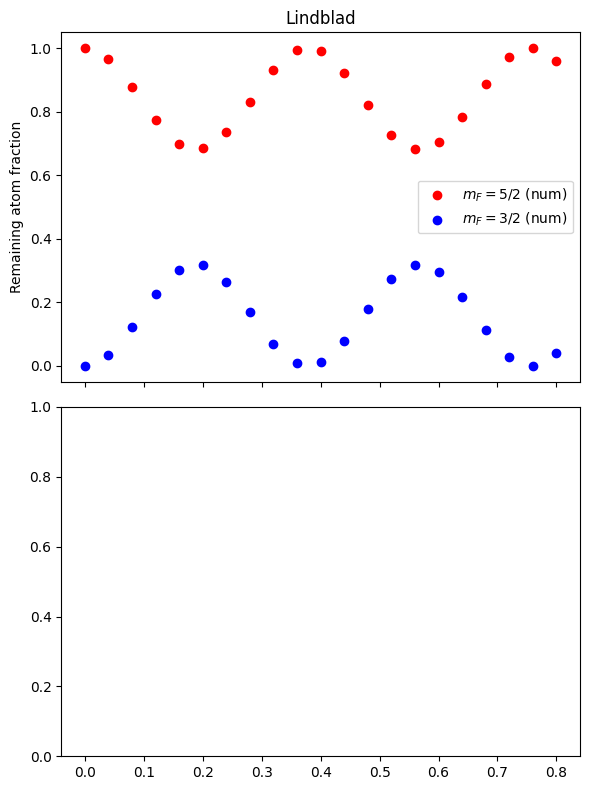

In [ ]:
fig, (ax_up, ax_down) = plt.subplots(2, 1, sharex=True, figsize=(6, 8))
ax_up.set_title(f"Lindblad")
ax_up.errorbar(ts_numerical, up_means_exp, yerr=up_ses_exp, fmt='o-', capsize=5, color='tomato', label='$m_F=5/2$ (exp)')
ax_up.errorbar(ts_numerical, down_means_exp, yerr=down_ses_exp, fmt='o-', capsize=5, color='cornflowerblue', label='$m_F=3/2$ (exp)')
ax_up.scatter(ts_numerical, up_means, label='$m_F=5/2$ (num)', color='red')
ax_up.scatter(ts_numerical, down_means, label='$m_F=3/2$ (num)', color='blue')
ax_up.legend()
ax_up.set_ylim(-0.05, 1.05)
ax_up.set_ylabel("Remaining atom fraction")
ax_down.errorbar(ts_numerical, remained_means_exp, yerr=remained_ses_exp, fmt='o-', capsize=5, color='grey', label='(exp)')
ax_down.errorbar(ts_numerical, remained_means, yerr=remained_errors, fmt='o', capsize=5, color='teal', label='(num)')
ax_down.set_ylim(0.45, 1.05)
ax_down.set_ylabel("Remaining atom fraction")
ax_down.legend()
ax_down.set_xlabel("$t\\,(ms)$")

plt.tight_layout()
plt.show()

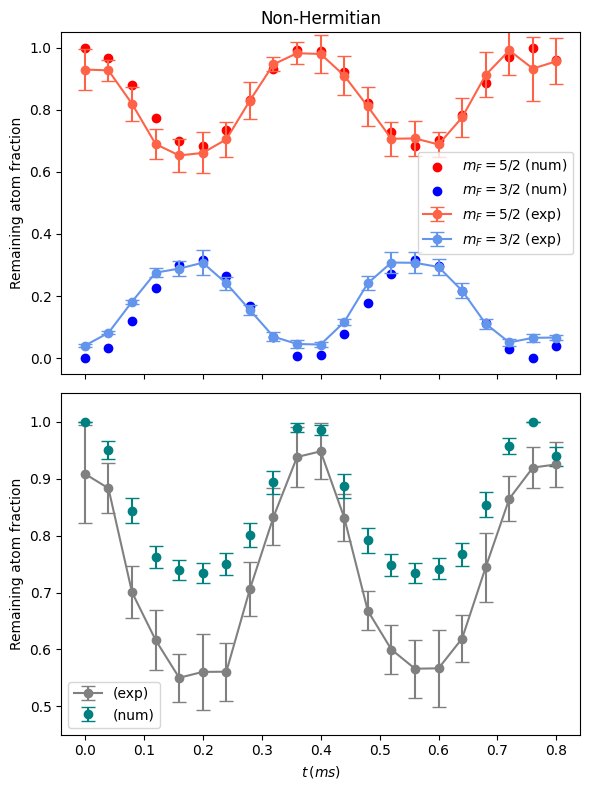

In [97]:
fig, (ax_up, ax_down) = plt.subplots(2, 1, sharex=True, figsize=(6, 8))
ax_up.set_title(f"Non-Hermitian")
ax_up.errorbar(ts_numerical, up_means_exp, yerr=up_ses_exp, fmt='o-', capsize=5, color='tomato', label='$m_F=5/2$ (exp)')
ax_up.errorbar(ts_numerical, down_means_exp, yerr=down_ses_exp, fmt='o-', capsize=5, color='cornflowerblue', label='$m_F=3/2$ (exp)')
ax_up.scatter(ts_numerical, up_means, label='$m_F=5/2$ (num)', color='red')
ax_up.scatter(ts_numerical, down_means, label='$m_F=3/2$ (num)', color='blue')
ax_up.legend()
ax_up.set_ylim(-0.05, 1.05)
ax_up.set_ylabel("Remaining atom fraction")
ax_down.errorbar(ts_numerical, remained_means_exp, yerr=remained_ses_exp, fmt='o-', capsize=5, color='grey', label='(exp)')
ax_down.errorbar(ts_numerical, remained_means_nh, yerr=remained_errors_nh, fmt='o', capsize=5, color='teal', label='(num)')
ax_down.set_ylim(0.45, 1.05)
ax_down.set_ylabel("Remaining atom fraction")
ax_down.legend()
ax_down.set_xlabel("$t\\,(ms)$")

plt.tight_layout()
plt.show()